In [1]:
import os
import glob
import sys


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb  # Has to be imported first to avoid conflicts with PyROOT
import json
from time import time
from datetime import timedelta
from yaml import safe_load, YAMLError, dump
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc
from xgboost import XGBClassifier


import config_copy as cfg ##################TO CHANGE ONCE DATA FINISHED PROCESSING
import efficiency_finder
#import variable_plotter as vp
plt.style.use('fcc.mplstyle')

In [2]:
# Function to load the BDT model from a JSON file
def load_bdt_model(json_path):
    bdt_model = xgb.Booster()
    bdt_model.load_model(json_path)
    return bdt_model

# Function to load the BDT model from a JSON file
def load_bdt_model_sklearn(json_path):
    bdt_model = XGBClassifier()
    bdt_model.load_model(json_path)
    return bdt_model

# Return list of variables to use in the bdt as a python list
def vars_fromyaml(path, bdtlist):
    with open(path) as stream:
        try:
            file = safe_load(stream)
            bdtvars = file[bdtlist]
        except YAMLError as exc:
            print(exc)
    return bdtvars

def load_bdt_and_apply(pickled_df_fname = "bdt-lh_dataframe.pkl", 
                        config_bdtopts = cfg.bdt_lh_opts,
                        training_round = "multiclass_baseline",
                        hps_dict_name = "default-hps",
                        features_list_name = "bdth-plus-vars",
                        bdt_label = '_lh'
                        ): # hps dict and features_list_name specift BDT used
    
    
    #path to data and outputs
    outputpath   = config_bdtopts['outputPath']
    yamlpath = cfg.fccana_opts['yamlPath']

    #Getting BDT vars for training from yaml
    bdtvars      = vars_fromyaml(yamlpath, features_list_name)
    bdtname      = f'BDT{bdt_label}_{hps_dict_name}_{features_list_name}'

    #path to pickled data
    pickled_df_path = os.path.join(outputpath, pickled_df_fname)

    #path to saved bdt
    bdt_json_path = os.path.join(outputpath,training_round,f"{bdtname}.json")

    # Load the BDT model
    try:
        print("Loading BDT model...")
        bdt_model = load_bdt_model_sklearn(bdt_json_path)
        print("BDT model loaded successfully.")
    except Exception as e:
        print(f"Error loading BDT model: {e}")
        quit()

    # Read df saved to pickle and add BDT 

    #Getting BDT vars for training from yaml
    # load pickled df
    df = pd.read_pickle(pickled_df_path)

    #add bdt score
    class_names = bdt_model.classes_
    probabilities = bdt_model.predict_proba(df[bdtvars])
    for i in range(probabilities.shape[1]):
        df[f'bdt_score_{class_names[i]}'] = probabilities[:, i]


    return bdt_model, bdtname, df

In [3]:
#multivariate map
labels = {'signal':2,'heavy_background':1 ,'light_background':0}
labels_dict_inverted = {v: k for k, v in labels.items()}
colors = {'signal':'mediumblue','heavy_background':'y' ,'light_background':'g','background':'r'}
blobs = {'signal':'bo','heavy_background':'y+' ,'light_background':'g+','background':'r+' }

In [4]:
model, bdtname, dataframe = load_bdt_and_apply( pickled_df_fname = "bdt_lh_dataframe.pkl", 
                        config_bdtopts = cfg.bdt_lh_opts,
                        training_round = "multiclass_baseline",
                        hps_dict_name = "default-hps",
                        features_list_name = "bdth-plus-vars",
                        bdt_label = '_lh')

outputpath = os.path.join(cfg.bdt_lh_opts['outputPath'],"multiclass_baseline")

Loading BDT model...
BDT model loaded successfully.


In [5]:
df = dataframe
lsearch = np.linspace(0.00005,0.005005,100)
hsearch= np.linspace(0.00005,0.00505,100)
eff_dict={}
eff_df=np.zeros((len(lsearch), len(hsearch)))
for decay in df["decay"].unique():
    eff_df=np.zeros((len(lsearch), len(hsearch)))
    subf = df[df["decay"]==decay]
    l_arr=[]
    h_arr=[]

    for l in np.arange(0,len(lsearch),1):
        for h in np.arange(0,len(hsearch),1):
            l_arr.append(lsearch[l])
            h_arr.append(hsearch[h])

            cutdf = subf[(subf["bdt_score_1"]<hsearch[h])&(subf["bdt_score_0"]<lsearch[l])]
            eff_lh = len(cutdf)/len(subf)
            eff_df[l][h] = eff_lh

    eff_dict[f"{decay}"] = eff_df
    

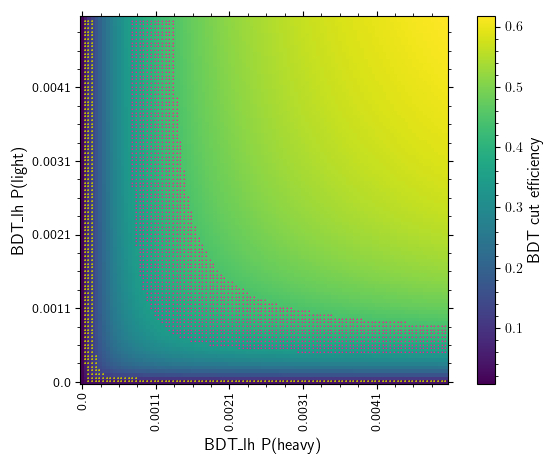

In [6]:
plt.figure()
plt.imshow(eff_dict['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu'], origin='lower')
plt.xlabel('BDT_lh P(heavy)')
plt.ylabel('BDT_lh P(light)')
plt.colorbar(label='BDT cut efficiency')

l_elements = sorted(list(set(l_arr)))
h_elements = sorted(list(set(h_arr)))

# Set tick labels for every 10th bin
ytick_indices = np.arange(0,len(l_elements), round(len(l_elements)/5))
xtick_indices = np.arange(0, len(h_elements), round(len(h_elements)/5))

# Use ytick_indices and xtick_indices to set the ticks
plt.yticks(ytick_indices, [round(l_elements[i],4) for i in ytick_indices])
plt.xticks(xtick_indices, [round(h_elements[i],4) for i in xtick_indices], rotation=90)
data = eff_dict['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu']


leff4=[]
heff4=[]
for l in np.arange(0,len(l_elements), 1):
    for h in np.arange(0,len(h_elements), 1): 
        if round(data[l,h],1)==0.4: 
            #print(round(data[l,h],1))
            leff4.append(lsearch[l])
            heff4.append(hsearch[l])
            plt.annotate('.', xy=(h, l), 
                     ha='center', va='center', color='deeppink',weight="bold") 
        if round(data[l,h],1)==0.1: 
            #print(round(data[l,h],1))
            plt.annotate('.', xy=(h, l), 
                     ha='center', va='center', color='y',weight="bold")
            plt.annotate('.', xy=(h, l), 
                     ha='center', va='center', color='y',weight="bold") 
            plt.annotate('.', xy=(h, l), 
                     ha='center', va='center', color='y',weight="bold") 
            plt.annotate('.', xy=(h, l), 
                     ha='center', va='center', color='y',weight="bold") 

  
plt.show()

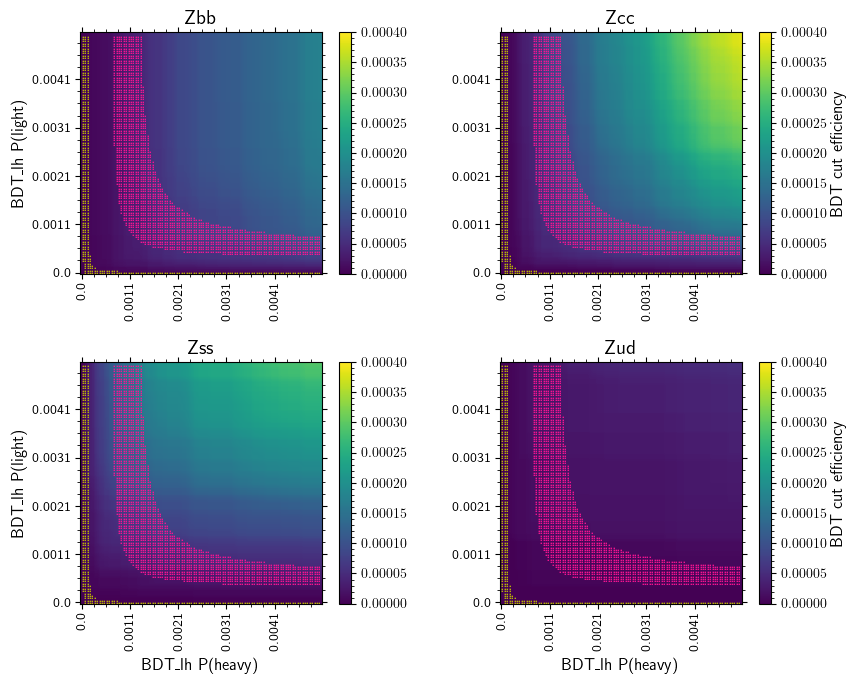

In [7]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(9,7))


h1 = axs[0,0].imshow(eff_dict['p8_ee_Zbb_ecm91'], origin='lower',vmin=0.0000,vmax=0.0004)
h2 = axs[0,1].imshow(eff_dict['p8_ee_Zcc_ecm91'], origin='lower',vmin=0.0000,vmax=0.0004)
h3 = axs[1,0].imshow(eff_dict['p8_ee_Zss_ecm91'], origin='lower',vmin=0.0000,vmax=0.0004)
h4 = axs[1,1].imshow(eff_dict['p8_ee_Zud_ecm91'], origin='lower',vmin=0.0000,vmax=0.0004)


# Big bins
axs[0, 0].set_title('Zbb')
axs[0,0].set_ylabel('BDT_lh P(light)')
#axs[0, 0].set_xticklabels([])
 
# Small bins
axs[0, 1].set_title('Zcc')
#axs[0, 1].set_xticklabels([])
#axs[0, 1].set_yticklabels([])


axs[1, 0].set_title('Zss')
axs[1,0].set_xlabel('BDT_lh P(heavy)')
axs[1,0].set_ylabel('BDT_lh P(light)')


axs[1, 1].set_title('Zud')
axs[1,1].set_xlabel('BDT_lh P(heavy)')
#axs[1, 1].set_yticklabels([])


l_elements = sorted(list(set(l_arr)))
h_elements = sorted(list(set(h_arr)))

# Set tick labels for every 10th bin
ytick_indices = np.arange(0,len(l_elements), round(len(l_elements)/5))
xtick_indices = np.arange(0, len(h_elements), round(len(h_elements)/5))

# Use ytick_indices and xtick_indices to set the ticks
axs[0,0].set_yticks(ytick_indices, [round(l_elements[i],4) for i in ytick_indices])
axs[0,0].set_xticks(xtick_indices, [round(h_elements[i],4) for i in xtick_indices], rotation=90)
axs[0,1].set_yticks(ytick_indices, [round(l_elements[i],4) for i in ytick_indices])
axs[0,1].set_xticks(xtick_indices, [round(h_elements[i],4) for i in xtick_indices], rotation=90)
axs[1,0].set_yticks(ytick_indices, [round(l_elements[i],4) for i in ytick_indices])
axs[1,0].set_xticks(xtick_indices, [round(h_elements[i],4) for i in xtick_indices], rotation=90)
axs[1,1].set_yticks(ytick_indices, [round(l_elements[i],4) for i in ytick_indices])
axs[1,1].set_xticks(xtick_indices, [round(h_elements[i],4) for i in xtick_indices], rotation=90)
             
data = eff_dict['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu']


leff4=[]
heff4=[]
for l in np.arange(0,len(l_elements), 1):
    for h in np.arange(0,len(h_elements), 1): 
        if round(data[l,h],1)==0.4: 
            #print(round(data[l,h],1))
            leff4.append(lsearch[l])
            heff4.append(hsearch[l])
            axs[0,0].annotate('.', xy=(h, l), 
                     ha='center', va='center', color='deeppink',weight="bold")
            axs[0,1].annotate('.', xy=(h, l), 
                     ha='center', va='center', color='deeppink',weight="bold") 
            axs[1,0].annotate('.', xy=(h, l), 
                     ha='center', va='center', color='deeppink',weight="bold") 
            axs[1,1].annotate('.', xy=(h, l), 
                     ha='center', va='center', color='deeppink',weight="bold") 

        if round(data[l,h],1)==0.1: 
            #print(round(data[l,h],1))
            axs[0,0].annotate('.', xy=(h, l), 
                     ha='center', va='center', color='y',weight="bold")
            axs[0,1].annotate('.', xy=(h, l), 
                     ha='center', va='center', color='y',weight="bold") 
            axs[1,0].annotate('.', xy=(h, l), 
                     ha='center', va='center', color='y',weight="bold") 
            axs[1,1].annotate('.', xy=(h, l), 
                     ha='center', va='center', color='y',weight="bold") 


# Visualizing colorbar 
fig.colorbar(h1, ax=axs[0, 0])
fig.colorbar(h2, ax=axs[0, 1],label='BDT cut efficiency')
fig.colorbar(h3, ax=axs[1, 0])
fig.colorbar(h4, ax=axs[1, 1],label='BDT cut efficiency')


plt.show()

In [8]:
bf_df = np.zeros((len(lsearch), len(hsearch)))


#approximate prelim cut eff
prelim_eff = {"p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu": 0.876, 
    "p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu": 0.884,  
    "p8_ee_Zbb_ecm91": 0.058,
    "p8_ee_Zcc_ecm91": 0.042,
    "p8_ee_Zss_ecm91": 0.046,
    "p8_ee_Zud_ecm91": 0.024,
}

N_z = 6e12
k = 2* cfg.prod_frac["Bs"] * cfg.branching_fractions["p8_ee_Zbb_ecm91"][0]*N_z*prelim_eff["p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu"]

sig_eff= eff_dict['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu']


for l in np.arange(0,len(l_elements), 1):
    for h in np.arange(0,len(h_elements), 1): 
        #3sigma bf for Bs so that comparable to old work
        K = k * sig_eff[l,h]
        B = sum([cfg.branching_fractions[s][0]*N_z*prelim_eff[s]* eff_dict[s][l,h] for s in cfg.sample_allocations["hadronic_background"]])
        bf =1/(2*K)*(9+np.sqrt(81+36*B))
        bf_df[l,h]=bf



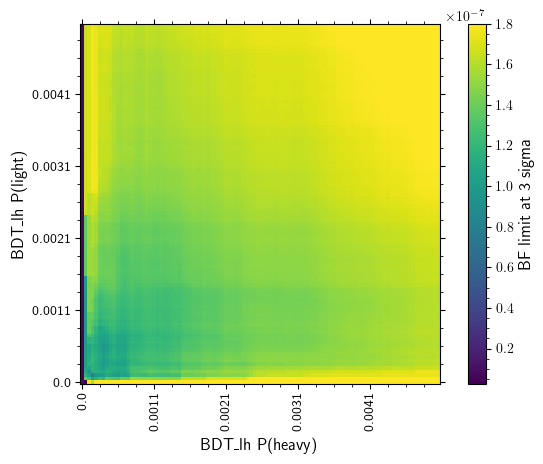

In [33]:
plt.figure()
plt.imshow(bf_df, origin='lower',vmax=1.8e-7)
plt.xlabel('BDT_lh P(heavy)')
plt.ylabel('BDT_lh P(light)')
plt.colorbar(label='BF limit at 3 sigma')

l_elements = sorted(list(set(l_arr)))
h_elements = sorted(list(set(h_arr)))

# Set tick labels for every 10th bin
ytick_indices = np.arange(0,len(l_elements), round(len(l_elements)/5))
xtick_indices = np.arange(0, len(h_elements), round(len(h_elements)/5))

# Use ytick_indices and xtick_indices to set the ticks
plt.yticks(ytick_indices, [round(l_elements[i],4) for i in ytick_indices])
plt.xticks(xtick_indices, [round(h_elements[i],4) for i in xtick_indices], rotation=90)

plt.show()

In [10]:
l_for_given_p = {}
h_for_given_p = {}
bf_for_given_p = {}
B_for_given_p = {}

#approximate prelim cut eff
prelim_eff = {"p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu": 0.876, 
    "p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu": 0.884,  
    "p8_ee_Zbb_ecm91": 0.058,
    "p8_ee_Zcc_ecm91": 0.042,
    "p8_ee_Zss_ecm91": 0.046,
    "p8_ee_Zud_ecm91": 0.024,
}

N_z = 6e12
k = 2* cfg.prod_frac["Bs"] * cfg.branching_fractions["p8_ee_Zbb_ecm91"][0]*N_z*prelim_eff["p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu"]

sig_eff= eff_dict['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu']

signal_efficieny_points = 0.1*np.arange(0.5,8,0.5)

for p in signal_efficieny_points:
    lcut=[]
    hcut=[]
    min_bfs = []
    B_arr=[]
    bf_B0_arr =[]
    sig_eff_arr_cut=[]

    for l in np.arange(0,len(l_elements), 1):
        for h in np.arange(0,len(h_elements), 1): 
            if data[l,h] < (round(p,2)+0.025) and data[l,h] > (round(p,2)-0.025): 
                #print(round(data[l,h],1))
                lcut.append(lsearch[l])
                hcut.append(hsearch[h])
                #3sigma bf for Bs so that comparable to old work
                K = k * sig_eff[l,h]
                B = sum([cfg.branching_fractions[s][0]*N_z*prelim_eff[s]* eff_dict[s][l,h] for s in cfg.sample_allocations["hadronic_background"]])
                bf =1/(2*K)*(9+np.sqrt(81+36*B))
                min_bfs.append(bf)
                B_arr.append(B)
                bf_B0 = 1/(2*K)*(9+np.sqrt(81))
                bf_B0_arr.append(bf_B0)
                sig_eff_arr_cut.append(data[l,h])
    
    bf_for_given_p[round(p,1)] = min_bfs
    l_for_given_p[round(p,1)] = lcut
    h_for_given_p[round(p,1)] = hcut
    B_for_given_p[round(p,1)] = B_arr

    print(f'For contour of signal efficiency within $\pm$ 0.025 of {round(p,2)} ' )

    if len(min_bfs) >0:
        print(f'Minimum BF at naive 3 sigma: {min(min_bfs)}')
        print(f'Total hadronic B at this cut= {B_arr[min_bfs.index(min(min_bfs))]}')
        print(f'signal eff at this cut= {sig_eff_arr_cut[min_bfs.index(min(min_bfs))]}')
        print(f'Minimum BF at naive 3 sigma if B==0: {bf_B0_arr[min_bfs.index(min(min_bfs))]}')
        print(f'cut on P(light) < {lcut[min_bfs.index(min(min_bfs))]}')
        print(f'cut on P(heavy) < {hcut[min_bfs.index(min(min_bfs))]}')
        print('-----------------------------------------------------------------')

    else:
        print(f'No points in efficiency scan satisfy Bs_eff = {p}')
        print('-----------------------------------------------------------------')



For contour of signal efficiency within $\pm$ 0.025 of 0.05 
Minimum BF at naive 3 sigma: 9.65234716296898e-08
Total hadronic B at this cut= 67735.20329826117
signal eff at this cut= 0.05332000645690424
Minimum BF at naive 3 sigma if B==0: 1.1062261988417414e-09
cut on P(light) < 0.0015014646464646465
cut on P(heavy) < 0.0001005050505050505
-----------------------------------------------------------------
For contour of signal efficiency within $\pm$ 0.025 of 0.1 
Minimum BF at naive 3 sigma: 8.229004810073284e-08
Total hadronic B at this cut= 142045.1358909092
signal eff at this cut= 0.09040807308693831
Minimum BF at naive 3 sigma if B==0: 6.524194803744799e-10
cut on P(light) < 0.0001501010101010101
cut on P(heavy) < 0.0002015151515151515
-----------------------------------------------------------------
For contour of signal efficiency within $\pm$ 0.025 of 0.15 
Minimum BF at naive 3 sigma: 1.0082881392126237e-07
Total hadronic B at this cut= 798368.634963925
signal eff at this cut=

In [29]:
df = dataframe
ssearch = np.linspace(0.990,1,100)

scut_eff_dict={}

for decay in df["decay"].unique():
    scut_eff_df=np.zeros((len(ssearch)))
    subf = df[df["decay"]==decay]
    s_arr=[]

    for l in np.arange(0,len(ssearch),1):
        s_arr.append(ssearch[l])

        cutdf = subf[(subf["bdt_score_2"]>ssearch[l])]
        eff_s = len(cutdf)/len(subf)
        scut_eff_df[l] = eff_s

    scut_eff_dict[f"{decay}"] = scut_eff_df
    

sig_eff= scut_eff_dict['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu']
#print(sig_eff)

s_elements = sorted(list(set(s_arr)))


s_for_given_p = {}
bf_for_given_p = {}
B_for_given_p = {}

for p in signal_efficieny_points:
    scut=[]
    min_bfs = []
    B_arr=[]
    bf_B0_arr =[]
    sig_eff_arr_cut=[]

    for l in np.arange(0,len(s_elements), 1):
  
        if sig_eff[l] < (round(p,2)+0.025) and sig_eff[l] > (round(p,2)-0.025): 
            scut.append(ssearch[l])
            #3sigma bf for Bs so that comparable to old work
            K = k * sig_eff[l]
            B = sum([cfg.branching_fractions[s][0]*N_z*prelim_eff[s]* scut_eff_dict[s][l] for s in cfg.sample_allocations["hadronic_background"]])
            bf =1/(2*K)*(9+np.sqrt(81+36*B))
            min_bfs.append(bf)
            B_arr.append(B)
            bf_B0 = 1/(2*K)*(9+np.sqrt(81))
            bf_B0_arr.append(bf_B0)
            sig_eff_arr_cut.append(sig_eff[l])
    
    bf_for_given_p[round(p,1)] = min_bfs
    s_for_given_p[round(p,1)] = scut
    B_for_given_p[round(p,1)] = B_arr

    print(f'For contour of signal efficiency within $\pm$ 0.025 of {round(p,2)} ' )

    if len(min_bfs) >0:
        print(f'Minimum BF at naive 3 sigma: {min(min_bfs)}')
        print(f'Total hadronic B at this cut= {B_arr[min_bfs.index(min(min_bfs))]}')
        print(f'signal eff at this cut= {sig_eff_arr_cut[min_bfs.index(min(min_bfs))]}')
        print(f'Minimum BF at naive 3 sigma if B==0: {bf_B0_arr[min_bfs.index(min(min_bfs))]}')
        print(f'cut on P(signal) > {scut[min_bfs.index(min(min_bfs))]}')
        print('-----------------------------------------------------------------')

    else:
        print(f'No points in efficiency scan satisfy Bs_eff = {p}')
        print('-----------------------------------------------------------------')


For contour of signal efficiency within $\pm$ 0.025 of 0.05 
Minimum BF at naive 3 sigma: 1.287018023536425e-07
Total hadronic B at this cut= 142045.1358909092
signal eff at this cut= 0.057805598266419046
Minimum BF at naive 3 sigma if B==0: 1.0203853923142216e-09
cut on P(signal) > 0.9997979797979798
-----------------------------------------------------------------
For contour of signal efficiency within $\pm$ 0.025 of 0.1 
Minimum BF at naive 3 sigma: 9.137514880961604e-08
Total hadronic B at this cut= 216355.06848355726
signal eff at this cut= 0.10040812200287952
Minimum BF at naive 3 sigma if B==0: 5.874423989659595e-10
cut on P(signal) > 0.9996969696969698
-----------------------------------------------------------------
For contour of signal efficiency within $\pm$ 0.025 of 0.15 
Minimum BF at naive 3 sigma: 1.0767158111049749e-07
Total hadronic B at this cut= 856902.7505275252
signal eff at this cut= 0.16930948626848003
Minimum BF at naive 3 sigma if B==0: 3.4837970018706043e-10

In [30]:
df = dataframe
ssearch = np.linspace(0.990,1,100)

scut_eff_dict={}

for decay in df["decay"].unique():
    scut_eff_df=np.zeros((len(ssearch)))
    subf = df[df["decay"]==decay]
    s_arr=[]

    for l in np.arange(0,len(ssearch),1):
        s_arr.append(ssearch[l])

        cutdf = subf[(subf["bdt_score_2"]*(1-subf["bdt_score_1"])*(1-subf["bdt_score_0"])>ssearch[l])]
        eff_s = len(cutdf)/len(subf)
        scut_eff_df[l] = eff_s

    scut_eff_dict[f"{decay}"] = scut_eff_df
    

sig_eff= scut_eff_dict['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu']
#print(sig_eff)

s_elements = sorted(list(set(s_arr)))


s_for_given_p = {}
bf_for_given_p = {}
B_for_given_p = {}

for p in signal_efficieny_points:
    scut=[]
    min_bfs = []
    B_arr=[]
    bf_B0_arr =[]
    sig_eff_arr_cut=[]

    for l in np.arange(0,len(s_elements), 1):
  
        if sig_eff[l] < (round(p,2)+0.025) and sig_eff[l] > (round(p,2)-0.025): 
            scut.append(ssearch[l])
            #3sigma bf for Bs so that comparable to old work
            K = k * sig_eff[l]
            B = sum([cfg.branching_fractions[s][0]*N_z*prelim_eff[s]* scut_eff_dict[s][l] for s in cfg.sample_allocations["hadronic_background"]])
            bf =1/(2*K)*(9+np.sqrt(81+36*B))
            min_bfs.append(bf)
            B_arr.append(B)
            bf_B0 = 1/(2*K)*(9+np.sqrt(81))
            bf_B0_arr.append(bf_B0)
            sig_eff_arr_cut.append(sig_eff[l])
    
    bf_for_given_p[round(p,1)] = min_bfs
    s_for_given_p[round(p,1)] = scut
    B_for_given_p[round(p,1)] = B_arr

    print(f'For contour of signal efficiency within $\pm$ 0.025 of {round(p,2)} ' )

    if len(min_bfs) >0:
        print(f'Minimum BF at naive 3 sigma: {min(min_bfs)}')
        print(f'Total hadronic B at this cut= {B_arr[min_bfs.index(min(min_bfs))]}')
        print(f'signal eff at this cut= {sig_eff_arr_cut[min_bfs.index(min(min_bfs))]}')
        print(f'Minimum BF at naive 3 sigma if B==0: {bf_B0_arr[min_bfs.index(min(min_bfs))]}')
        print(f'cut on P(signal)(1-P(l))(1-P(h)) > {scut[min_bfs.index(min(min_bfs))]}')
        print('-----------------------------------------------------------------')

    else:
        print(f'No points in efficiency scan satisfy Bs_eff = {p}')
        print('-----------------------------------------------------------------')


For contour of signal efficiency within $\pm$ 0.025 of 0.05 
Minimum BF at naive 3 sigma: 1.2862198503245573e-07
Total hadronic B at this cut= 142045.1358909092
signal eff at this cut= 0.05784146995664417
Minimum BF at naive 3 sigma if B==0: 1.019752577333365e-09
cut on P(signal)(1-P(l))(1-P(h)) > 0.9995959595959596
-----------------------------------------------------------------
For contour of signal efficiency within $\pm$ 0.025 of 0.1 
Minimum BF at naive 3 sigma: 9.134844741219124e-08
Total hadronic B at this cut= 216355.06848355726
signal eff at this cut= 0.10043747156760917
Minimum BF at naive 3 sigma if B==0: 5.872707381461053e-10
cut on P(signal)(1-P(l))(1-P(h)) > 0.9993939393939394
-----------------------------------------------------------------
For contour of signal efficiency within $\pm$ 0.025 of 0.15 
Minimum BF at naive 3 sigma: 1.0763944590991188e-07
Total hadronic B at this cut= 856902.7505275252
signal eff at this cut= 0.16936003274106998
Minimum BF at naive 3 sigma 